# Supplementary Figure S2

Submitted 3 × 2 quantitative benchmark.

Run from top to bottom. All scientific and plotting code is contained in this notebook.

## Data lineage

Packaged source table(s): `data/figs2.csv`. They were deterministically extracted by `scripts/reviewer_data/extract_figure_data.py` from retained author analysis tables and manuscript-frozen contracts. The cells below expose every reviewer-side filter, sort, grouping, pivot, coordinate calculation, and plot export. Checksums, schemas, row counts, privacy class, and extraction metadata are recorded in `data/manifest.json`.


In [1]:
from pathlib import Path
from typing import Any
import hashlib
import json
import math
import os

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from matplotlib.path import Path as MplPath
from matplotlib.patches import FancyBboxPatch, PathPatch
from IPython.display import Image, Markdown, display

# Locate For_Reviewer when Jupyter starts in the repository root,
# For_Reviewer, or For_Reviewer/notebooks.
_candidates = []
for _base in (Path.cwd(), *Path.cwd().parents):
    _candidates.extend((_base, _base / "For_Reviewer"))
ROOT = next(
    (
        _path.resolve()
        for _path in _candidates
        if (_path / "notebooks" / "Data_Preparation.ipynb").is_file() and (_path / "README.md").is_file()
    ),
    None,
)
if ROOT is None:
    raise RuntimeError("Could not locate the For_Reviewer folder.")

DATA = Path(os.environ.get("LINKD_REPRO_DATA_DIR", ROOT / "data")).resolve()
STATIC = Path(os.environ.get("LINKD_REPRO_STATIC_DIR", ROOT / "static")).resolve()
MANIFEST = DATA / "manifest.json"
RECOVERY_COMMAND = "Open notebooks/Data_Preparation.ipynb and choose Restart Kernel and Run All."
if not MANIFEST.is_file():
    raise FileNotFoundError(f"Missing {MANIFEST}. {RECOVERY_COMMAND}")

_manifest_entries = json.loads(MANIFEST.read_text(encoding="utf-8"))
_manifest_by_path = {entry["path"]: entry for entry in _manifest_entries}

def verify_input(path):
    """Verify a packaged panel table immediately before loading it."""
    relative = path.relative_to(DATA).as_posix()
    entry = _manifest_by_path.get(relative)
    if entry is None or not path.is_file():
        raise FileNotFoundError(f"Missing packaged input: {path}. {RECOVERY_COMMAND}")
    digest = hashlib.sha256(path.read_bytes()).hexdigest()
    if digest != entry["sha256"]:
        raise RuntimeError(f"Checksum mismatch for {path}. {RECOVERY_COMMAND}")

PANELS = DATA
ILLUSTRATIONS = STATIC
OUTPUT_ROOT = Path(os.environ.get("LINKD_REPRO_OUTPUT_DIR", ROOT / "outputs")).resolve()
OUTPUT_FIG = OUTPUT_ROOT / "figures"
OUTPUT_DATA = OUTPUT_ROOT / "source_data"
OUTPUT_FIG.mkdir(parents=True, exist_ok=True)
OUTPUT_DATA.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 8, "axes.labelsize": 8, "axes.titlesize": 9,
    "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 7,
    "axes.linewidth": 0.6, "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "pdf.fonttype": 42, "ps.fonttype": 42, "figure.dpi": 150, "savefig.dpi": 300,
    "axes.spines.top": False, "axes.spines.right": False,
})
BLUE = "#4C78A8"; RED = "#E45756"; TEAL = "#2A9D8F"; ORANGE = "#F4A261"; GREY = "#B8B8B8"

def panel_label(ax, value):
    ax.text(-0.15, 1.05, value, transform=ax.transAxes, fontsize=11,
            fontweight="bold", va="top")

def show_static(panel_id, title):
    """Display a submitted static panel and its bundled provenance note."""
    folder = ILLUSTRATIONS / panel_id
    process = folder / "PROCESS.md"
    if not process.is_file():
        raise FileNotFoundError(f"Missing provenance: {process}. {RECOVERY_COMMAND}")
    display(Markdown(f"### {title}\n\n" + process.read_text(encoding="utf-8")))
    assets = sorted([
        *folder.glob("*.png"), *folder.glob("*.jpg"),
        *folder.glob("*.jpeg"), *folder.glob("*.pdf"),
    ])
    if not assets:
        raise FileNotFoundError(f"Missing submitted asset in {folder}. {RECOVERY_COMMAND}")
    raster = next(
        (path for path in assets if path.suffix.lower() in {".png", ".jpg", ".jpeg"}),
        None,
    )
    if raster is not None:
        display(Image(filename=str(raster), width=720))
    else:
        display(Markdown(f"Submitted PDF asset: `{assets[0]}`"))

print("Reviewer package:", ROOT)
print("Panel data:", DATA)
print("Static assets:", STATIC)
print("Outputs:", OUTPUT_ROOT)



Reviewer package: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer
Panel data: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/data
Static assets: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/static
Outputs: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs


## figS2 — Supplementary benchmark grid

This section contains the complete data loading, validation, transformation, plotting, and export code for this submitted panel.

In [2]:
verify_input(PANELS / "figs2.csv")
data = pd.read_csv(PANELS / "figs2.csv")
print("shape:", data.shape)
print("columns:", data.columns.tolist())
display(data.head())

shape: (45, 7)
columns: ['model', 'split', 'dataset', 'rmse_mean', 'rmse_sd', 'pearson_mean', 'pearson_sd']


,model,split,dataset,rmse_mean,rmse_sd,pearson_mean,pearson_sd
0,DeepDTA,Cold-drug,BindDB,1.134487,NaN,0.542575,NaN
1,DeepDTA,Cold-drug,Davis,0.661075,NaN,0.091171,NaN
2,DeepDTA,Cold-drug,Kiba,0.764556,NaN,0.402373,NaN
3,DeepDTA,Cold-protein,BindDB,1.214678,NaN,0.324045,NaN
4,DeepDTA,Cold-protein,Davis,0.729680,NaN,NaN,NaN


In [3]:
assert set(data["split"]) == {"Random", "Cold-drug", "Cold-protein"}
assert set(data["dataset"]) == {"BindDB", "Davis", "Kiba"}
print("PASS — figS2 manuscript invariants")

PASS — figS2 manuscript invariants


In [4]:
prepared = data.copy()
print("prepared shape:", prepared.shape)
display(prepared.head())

prepared shape: (45, 7)


,model,split,dataset,rmse_mean,rmse_sd,pearson_mean,pearson_sd
0,DeepDTA,Cold-drug,BindDB,1.134487,NaN,0.542575,NaN
1,DeepDTA,Cold-drug,Davis,0.661075,NaN,0.091171,NaN
2,DeepDTA,Cold-drug,Kiba,0.764556,NaN,0.402373,NaN
3,DeepDTA,Cold-protein,BindDB,1.214678,NaN,0.324045,NaN
4,DeepDTA,Cold-protein,Davis,0.729680,NaN,NaN,NaN


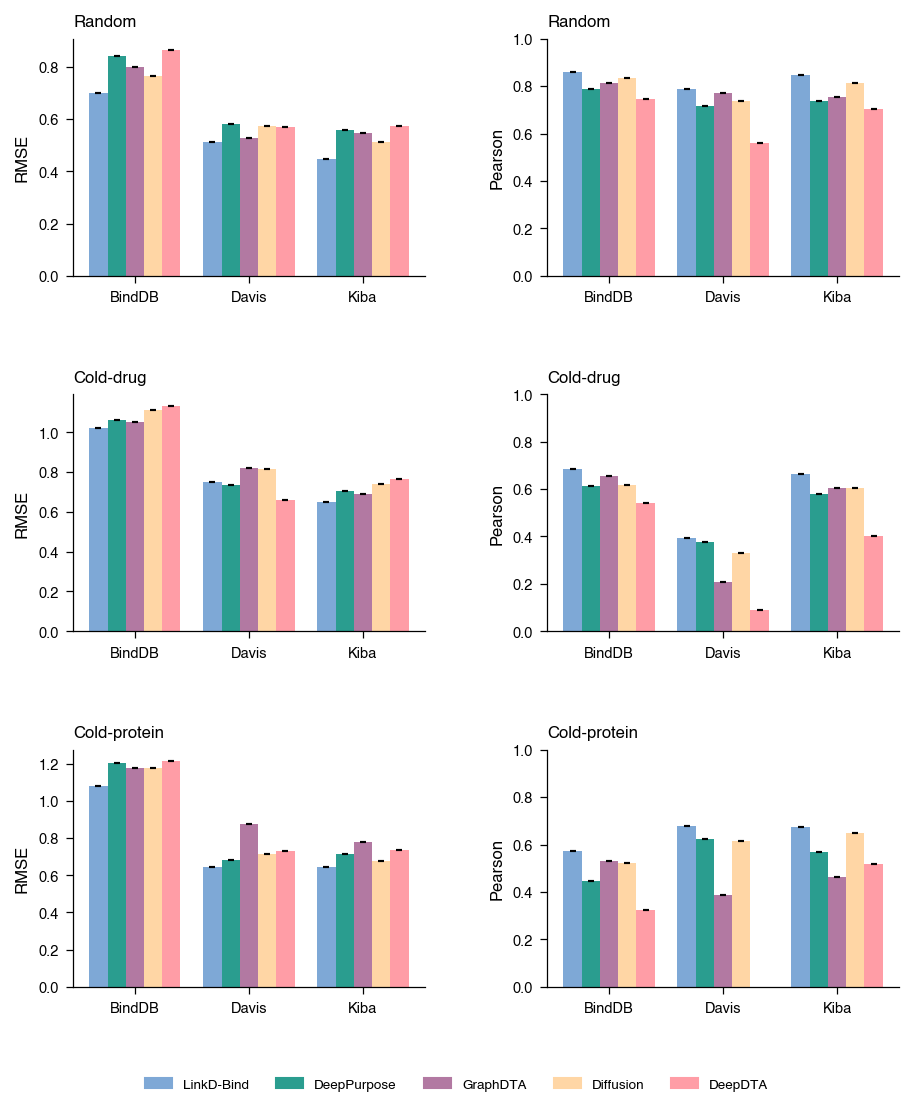

In [5]:
def plot_figs2(data: pd.DataFrame) -> tuple[plt.Figure, pd.DataFrame]:
    splits = ["Random", "Cold-drug", "Cold-protein"]
    models = ["LinkD-Bind", "DeepPurpose", "GraphDTA", "Diffusion", "DeepDTA"]
    datasets = ["BindDB", "Davis", "Kiba"]
    colors = dict(zip(models, ["#7EA8D6", TEAL, "#B279A2", "#FFD6A5", "#FF9DA6"]))
    fig, axes = plt.subplots(3, 2, figsize=(7.1, 8)); width = 0.16
    for row, split in enumerate(splits):
        for col, (mean, sd, ylabel) in enumerate([
            ("rmse_mean", "rmse_sd", "RMSE"), ("pearson_mean", "pearson_sd", "Pearson")
        ]):
            ax = axes[row, col]
            for i, model in enumerate(models):
                sub = data[(data["split"] == split) & (data["model"] == model)].set_index("dataset").reindex(datasets)
                xx = np.arange(3) + (i - 2) * width
                ax.bar(xx, sub[mean], width, color=colors[model])
                ax.errorbar(xx, sub[mean], yerr=sub[sd].fillna(0), fmt="none", ecolor="black", lw=.5, capsize=1.5)
            ax.set_xticks(range(3), datasets); ax.set_ylabel(ylabel)
            ax.set_title(split, loc="left", fontsize=8, fontweight="bold")
            if ylabel == "Pearson": ax.set_ylim(0, 1)
    fig.legend([plt.Rectangle((0, 0), 1, 1, color=colors[m]) for m in models],
               models, loc="lower center", ncol=5, frameon=False, fontsize=6.5)
    fig.subplots_adjust(bottom=.09, hspace=.5, wspace=.35)
    return fig, data


figure, plotted_source = plot_figs2(prepared)
display(figure)
plt.close(figure)

In [6]:
pdf_path = OUTPUT_FIG / "figS2_benchmark.pdf"
png_path = OUTPUT_FIG / "figS2_benchmark.png"
csv_path = OUTPUT_DATA / "figS2_benchmark.csv"
figure.savefig(pdf_path, bbox_inches="tight", metadata={"Title": "figS2_benchmark", "Author": "LinkD figure reproduction package", "Creator": "matplotlib"})
figure.savefig(png_path, bbox_inches="tight", dpi=300)
plotted_source.to_csv(csv_path, index=False, lineterminator="\n")
assert pdf_path.stat().st_size > 0 and png_path.stat().st_size > 0 and csv_path.stat().st_size > 0
print("PDF:", pdf_path)
print("PNG:", png_path)
print("CSV:", csv_path)
print("Panel result: The submitted 3×2 layout is reproduced.")

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


PDF: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/figS2_benchmark.pdf
PNG: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/figS2_benchmark.png
CSV: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/source_data/figS2_benchmark.csv
Panel result: The submitted 3×2 layout is reproduced.


## Complete

All assigned panels were displayed inline and exported as PDF, PNG, and source CSV where computational.